In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Score

In [2]:
def score_mu(y, mu, phi, beta, xi):
    """
    Score da locação:
        nabla_mu = d ell / d mu

    Parâmetros
    ----------
    y : array-like
        Observação y_t.
    mu : array-like ou float
        Parâmetro de locação mu_t.
    phi : array-like ou float
        Parâmetro de escala phi_t > 0.
    beta : array-like ou float
        Parâmetro beta_t > 0.
    xi : array-like ou float
        Parâmetro de forma xi_t.

    Retorna
    -------
    score : ndarray ou float
        Score nabla_t^mu.
    """

    y, mu, phi, beta, xi = np.broadcast_arrays(
        np.asarray(y, dtype=float),
        np.asarray(mu, dtype=float),
        np.asarray(phi, dtype=float),
        np.asarray(beta, dtype=float),
        np.asarray(xi, dtype=float)
    )

    z = (y - mu) / phi

    score = np.empty_like(z)

    mask_zero = (xi == 0)
    mask_nonzero = ~mask_zero

    # xi != 0
    if np.any(mask_nonzero):
        xi_nz = xi[mask_nonzero]
        phi_nz = phi[mask_nonzero]
        beta_nz = beta[mask_nonzero]
        z_nz = z[mask_nonzero]

        A = 1 + xi_nz * z_nz

        score[mask_nonzero] = (
            -(beta_nz - 1) / phi_nz
            * A**(-1 / xi_nz - 1)
            / (1 - A**(-1 / xi_nz))
            + (1 + xi_nz) / phi_nz / A
        )

    # xi = 0
    if np.any(mask_zero):
        phi_0 = phi[mask_zero]
        beta_0 = beta[mask_zero]
        z_0 = z[mask_zero]

        exp_neg_z = np.exp(-z_0)

        score[mask_zero] = (
            -(beta_0 - 1) / phi_0
            * exp_neg_z
            / (1 - exp_neg_z)
            + 1 / phi_0
        )

    return score

In [ ]:
def egpd_pdf_z(z, beta, xi):
    """
    Densidade do EGPD padronizado em z.
    """

    if xi == 0:
        return (
            beta
            * (1 - np.exp(-z))**(beta - 1)
            * np.exp(-z)
        )

    A = 1 + xi * z

    if A <= 0:
        return 0.0

    return (
        beta
        * (1 - A**(-1 / xi))**(beta - 1)
        * A**(-1 / xi - 1)
    )


def expected_score_mu_numerical(beta, xi, phi=1.0):
    """
    Calcula numericamente E[nabla_mu].
    """

    def integrand(z):
        score = score_mu(
            y=z * phi,
            mu=0.0,
            phi=phi,
            beta=beta,
            xi=xi
        )

        density = egpd_pdf_z(z, beta, xi)

        return score * density

    if xi < 0:
        upper = -1 / xi
    else:
        upper = np.inf

    value, error = quad(
        integrand,
        0,
        upper,
        limit=500
    )

    return value, error

In [3]:
def score_phi(y, mu, phi, beta, xi):
    """
    Score da escala transformada:
        tilde_nabla_phi = d ell / d tilde(phi)

    onde:
        tilde(phi) = log(phi)

    Retorna o score em relação a tilde(phi), e não em relação
    diretamente a phi.
    """

    y, mu, phi, beta, xi = np.broadcast_arrays(
        np.asarray(y, dtype=float),
        np.asarray(mu, dtype=float),
        np.asarray(phi, dtype=float),
        np.asarray(beta, dtype=float),
        np.asarray(xi, dtype=float)
    )

    z = (y - mu) / phi

    score = np.empty_like(z)

    mask_zero = (xi == 0)
    mask_nonzero = ~mask_zero

    # xi != 0
    if np.any(mask_nonzero):
        xi_nz = xi[mask_nonzero]
        beta_nz = beta[mask_nonzero]
        z_nz = z[mask_nonzero]

        A = 1 + xi_nz * z_nz

        score[mask_nonzero] = (
            -1
            - (beta_nz - 1)
            * z_nz
            * A**(-1 / xi_nz - 1)
            / (1 - A**(-1 / xi_nz))
            + (1 + xi_nz) * z_nz / A
        )

    # xi = 0
    if np.any(mask_zero):
        beta_0 = beta[mask_zero]
        z_0 = z[mask_zero]

        exp_neg_z = np.exp(-z_0)

        score[mask_zero] = (
            -1
            - (beta_0 - 1)
            * z_0
            * exp_neg_z
            / (1 - exp_neg_z)
            + z_0
        )

    return score

In [4]:
def score_beta(y, mu, phi, beta, xi):
    """
    Score do beta transformado:
        tilde_nabla_beta = d ell / d tilde(beta)

    onde:
        tilde(beta) = log(beta)
    """

    y, mu, phi, beta, xi = np.broadcast_arrays(
        np.asarray(y, dtype=float),
        np.asarray(mu, dtype=float),
        np.asarray(phi, dtype=float),
        np.asarray(beta, dtype=float),
        np.asarray(xi, dtype=float)
    )

    z = (y - mu) / phi

    score = np.empty_like(z)

    mask_zero = (xi == 0)
    mask_nonzero = ~mask_zero

    # xi != 0
    if np.any(mask_nonzero):
        xi_nz = xi[mask_nonzero]
        beta_nz = beta[mask_nonzero]
        z_nz = z[mask_nonzero]

        A = 1 + xi_nz * z_nz

        score[mask_nonzero] = (
            1
            + beta_nz
            * np.log(1 - A**(-1 / xi_nz))
        )

    # xi = 0
    if np.any(mask_zero):
        beta_0 = beta[mask_zero]
        z_0 = z[mask_zero]

        score[mask_zero] = (
            1
            + beta_0
            * np.log(1 - np.exp(-z_0))
        )

    return score

In [ ]:
beta = 3.0
phi = 2.0

for xi in [-0.5, -0.2, 0.0, 0.2, 0.5, 1.0]:

    value, error = expected_score_mu_numerical(
        beta=beta,
        xi=xi,
        phi=phi
    )

    print(
        f"xi = {xi:5.2f} | "
        f"E[score_mu] = {value: .8e} | "
        f"erro = {error:.2e}"
    )

In [19]:
# def score_xi(y, mu, phi, beta, xi):
#     """
#     Score do parâmetro de forma:
#         nabla_xi = d ell / d xi
#     """

#     y, mu, phi, beta, xi = np.broadcast_arrays(
#         np.asarray(y, dtype=float),
#         np.asarray(mu, dtype=float),
#         np.asarray(phi, dtype=float),
#         np.asarray(beta, dtype=float),
#         np.asarray(xi, dtype=float)
#     )

#     z = (y - mu) / phi

#     score = np.empty_like(z)

#     mask_zero = (xi == 0)
#     mask_nonzero = ~mask_zero

#     # xi != 0
#     if np.any(mask_nonzero):
#         xi_nz = xi[mask_nonzero]
#         beta_nz = beta[mask_nonzero]
#         z_nz = z[mask_nonzero]

#         A = 1 + xi_nz * z_nz

#         A_power = A**(-1 / xi_nz)

#         score[mask_nonzero] = (
#             -(beta_nz - 1)
#             * A_power
#             / (1 - A_power)
#             * (
#                 np.log(A) / xi_nz**2
#                 - z_nz / (xi_nz * A)
#             )
#             + np.log(A) / xi_nz**2
#             - (1 + xi_nz) * z_nz / (xi_nz * A)
#         )

#     # xi = 0
#     if np.any(mask_zero):
#         beta_0 = beta[mask_zero]
#         z_0 = z[mask_zero]

#         exp_neg_z = np.exp(-z_0)

#         score[mask_zero] = (
#             -(beta_0 - 1) / 2
#             * z_0**2
#             * exp_neg_z
#             / (1 - exp_neg_z)
#             - z_0
#             + z_0**2 / 2
#         )

#     return score

In [20]:
def score_xi(y, mu, phi, beta, xi):
    """
    Score do parâmetro de forma:
        nabla_xi = d ell / d xi

    Implementa exatamente as expressões definidas para:
        xi != 0
        xi = 0

    A expressão para xi != 0 é reescrita de forma
    numericamente estável para valores de xi próximos de zero.

    Parâmetros
    ----------
    y : array-like ou float
        Observação y_t.
    mu : array-like ou float
        Parâmetro de locação mu_t.
    phi : array-like ou float
        Parâmetro de escala phi_t > 0.
    beta : array-like ou float
        Parâmetro beta_t > 0.
    xi : array-like ou float
        Parâmetro de forma xi_t.

    Retorna
    -------
    score : ndarray ou float
        Score nabla_t^xi.
    """

    y, mu, phi, beta, xi = np.broadcast_arrays(
        np.asarray(y, dtype=float),
        np.asarray(mu, dtype=float),
        np.asarray(phi, dtype=float),
        np.asarray(beta, dtype=float),
        np.asarray(xi, dtype=float)
    )

    z = (y - mu) / phi

    score = np.empty_like(z)

    mask_zero = (xi == 0)
    mask_nonzero = ~mask_zero

    # ========================================================
    # xi != 0
    # ========================================================

    if np.any(mask_nonzero):

        xi_nz = xi[mask_nonzero]
        beta_nz = beta[mask_nonzero]
        z_nz = z[mask_nonzero]

        u = xi_nz * z_nz
        A = 1.0 + u

        # ----------------------------------------------------
        # log(1 + xi*z), calculado de forma estável
        # ----------------------------------------------------

        log_A = np.log1p(u)

        # ----------------------------------------------------
        # h(u) =
        # [(1+u) log(1+u) - u] / u^2
        #
        # Para u próximo de zero usamos a expansão:
        #
        # h(u) = 1/2 - u/6 + u^2/12
        #        - u^3/20 + u^4/30 - ...
        # ----------------------------------------------------

        h = np.empty_like(u)

        small_u = np.abs(u) < 1e-4
        regular_u = ~small_u

        if np.any(regular_u):
            u_r = u[regular_u]

            h[regular_u] = (
                (1.0 + u_r) * np.log1p(u_r) - u_r
            ) / (u_r ** 2)

        if np.any(small_u):
            u_s = u[small_u]

            h[small_u] = (
                0.5
                - u_s / 6.0
                + u_s**2 / 12.0
                - u_s**3 / 20.0
                + u_s**4 / 30.0
                - u_s**5 / 42.0
            )

        # ----------------------------------------------------
        # Termo que anteriormente aparecia como:
        #
        # log(A)/xi^2 - z/[xi*A]
        #
        # agora calculado de forma estável:
        #
        # z^2 h(u) / A
        # ----------------------------------------------------

        bracket = z_nz**2 * h / A

        # ----------------------------------------------------
        # A^(-1/xi) / [1 - A^(-1/xi)]
        #
        # = 1 / [exp(log(A)/xi) - 1]
        #
        # expm1 evita perda de precisão quando o argumento
        # é pequeno.
        # ----------------------------------------------------

        exponent = log_A / xi_nz

        ratio = 1.0 / np.expm1(exponent)

        # ----------------------------------------------------
        # Segundo bloco:
        #
        # log(A)/xi^2
        # -
        # (1+xi) z / (xi A)
        #
        # pode ser escrito como:
        #
        # bracket - z/A
        # ----------------------------------------------------

        score[mask_nonzero] = (
            -(beta_nz - 1.0) * ratio * bracket
            + bracket
            - z_nz / A
        )

    # ========================================================
    # xi = 0
    # ========================================================

    if np.any(mask_zero):

        beta_0 = beta[mask_zero]
        z_0 = z[mask_zero]

        exp_neg_z = np.exp(-z_0)

        score[mask_zero] = (
            -(beta_0 - 1.0) / 2.0
            * z_0**2
            * exp_neg_z
            / (1.0 - exp_neg_z)
            - z_0
            + z_0**2 / 2.0
        )

    return score

# Testes

In [24]:
y = 10.0
mu = 2.0
phi = 3.0
beta = 1.5
xi = 0.2

mu_grid = np.linspace(-2, 9, 500)
score_mu_xi = score_mu(y=y, mu=mu_grid, phi=phi, beta=beta, xi=0.2)
score_mu_xi0 = score_mu(y=y, mu=mu_grid, phi=phi, beta=beta, xi=0.0)

phi_grid = np.linspace(0.2, 10, 500)
score_phi_xi = score_phi(y=y, mu=mu, phi=phi_grid, beta=beta, xi=0.2)
score_phi_xi0 = score_phi(y=y, mu=mu, phi=phi_grid, beta=beta, xi=0.0)

beta_grid = np.linspace(0.1, 5, 500)
score_beta_xi = score_beta(y=y, mu=mu, phi=phi, beta=beta_grid, xi=0.2)
score_beta_xi0 = score_beta(y=y, mu=mu, phi=phi, beta=beta_grid, xi=0.0)

xi_grid = np.linspace(-0.4, 0.4, 1000)
score_xi = score_xi(y=y, mu=mu, phi=phi, beta=beta, xi=xi_grid)

C:\Users\aless\AppData\Local\Temp\ipykernel_46376\461818756.py:64: RuntimeWarning: invalid value encountered in log1p
  log_A = np.log1p(u)
C:\Users\aless\AppData\Local\Temp\ipykernel_46376\461818756.py:85: RuntimeWarning: invalid value encountered in log1p
  (1.0 + u_r) * np.log1p(u_r) - u_r


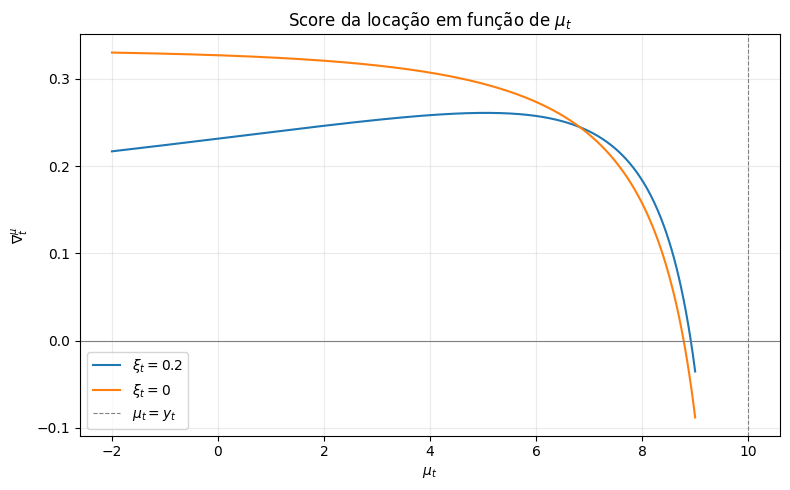

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(mu_grid, score_mu_xi, label=r'$\xi_t=0.2$')
plt.plot(mu_grid, score_mu_xi0, label=r'$\xi_t=0$')

plt.axhline(0, linewidth=0.8, color='gray')
plt.axvline(y, linestyle='--', linewidth=0.8, label=r'$\mu_t=y_t$', color='gray')

plt.xlabel(r'$\mu_t$')
plt.ylabel(r'$\nabla_t^\mu$')
plt.title(r'Score da locação em função de $\mu_t$')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

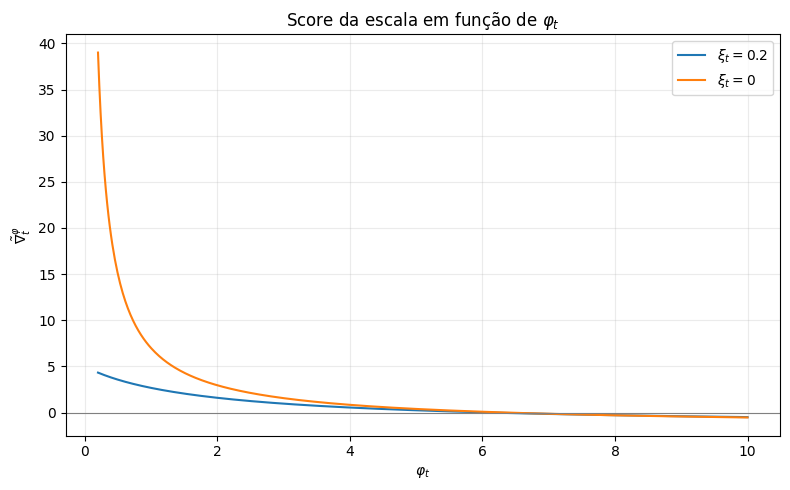

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(phi_grid, score_phi_xi, label=r'$\xi_t=0.2$')
plt.plot(phi_grid, score_phi_xi0, label=r'$\xi_t=0$')

plt.axhline(0, linewidth=0.8, color='gray')

plt.xlabel(r'$\varphi_t$')
plt.ylabel(r'$\tilde{\nabla}_t^\varphi$')
plt.title(r'Score da escala em função de $\varphi_t$')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

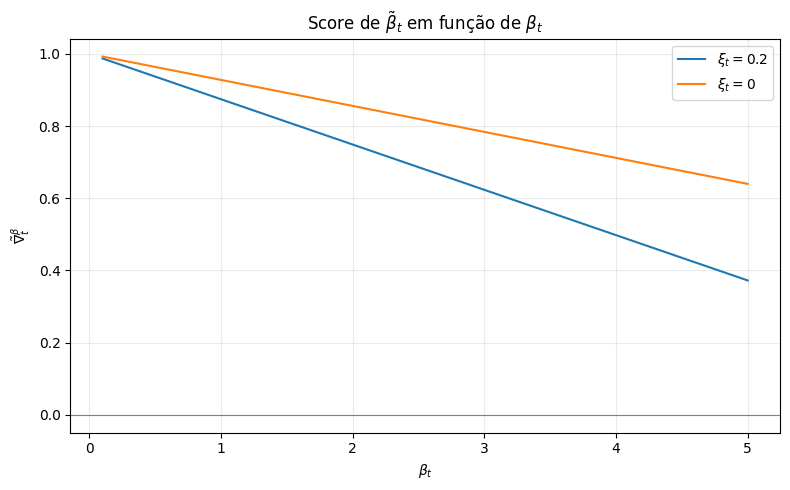

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(beta_grid, score_beta_xi, label=r'$\xi_t=0.2$')
plt.plot(beta_grid, score_beta_xi0, label=r'$\xi_t=0$')

plt.axhline(0, linewidth=0.8, color='gray')

plt.xlabel(r'$\beta_t$')
plt.ylabel(r'$\tilde{\nabla}_t^\beta$')
plt.title(r'Score de $\tilde{\beta}_t$ em função de $\beta_t$')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

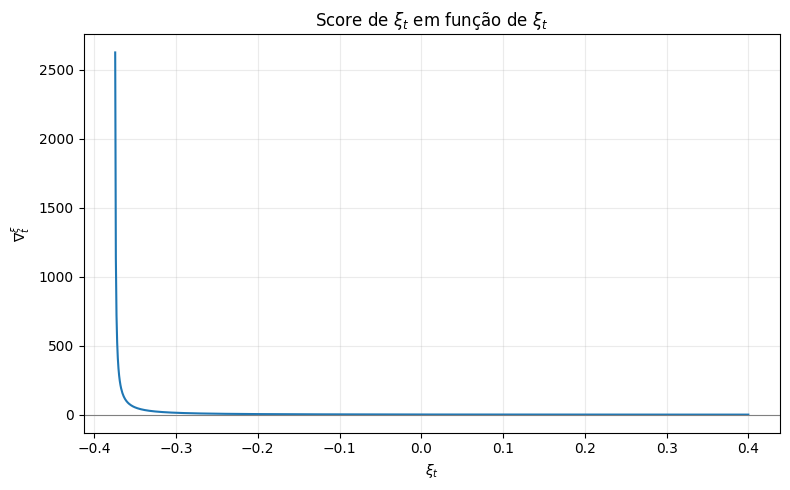

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(xi_grid, score_xi, linewidth=1.5)
plt.axhline(0, linewidth=0.8, color='gray')

plt.xlabel(r'$\xi_t$')
plt.ylabel(r'$\nabla_t^\xi$')
plt.title(r'Score de $\xi_t$ em função de $\xi_t$')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()